# DATA 37100 — Final Project Analysis

**Author:** Chenqi Wang

## Core Question

> How do target parameterization (eps vs x0) and model capacity (base_ch) affect diffusion sample quality on MNIST?

## Models Used
- **Diffusion** — primary model, used for the controlled two-knob experiment
- **GAN** — second baseline to demonstrate a different generative paradigm

## Experiment Summary
- **Knob 1:** target ∈ {eps, x0}
- **Knob 2:** base_ch ∈ {32, 64, 128}
- **Fixed:** T=200, beta1=1e-4, beta2=0.02, lr=2e-4, epochs=1, bs=128, seed=42
- **Total runs:** 6 (2 × 3 grid) + 1 GAN baseline


## 1. Setup

Run this notebook from the **repo root** directory.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Notebook lives at <repo>/final/analysis/, so go up two levels to reach repo root
REPO_ROOT = Path('.').resolve().parent.parent

DIFF_OUT = REPO_ROOT / 'untrack' / 'outputs' / 'final' / 'diffusion'
GAN_OUT  = REPO_ROOT / 'untrack' / 'outputs' / 'final' / 'gan'

GAN_BASELINE = GAN_OUT / 'ds-mnist_ep-1_bs-128_lr-0.0002_dsteps-1_z-128_ch-64_seed-42'
DIFF_BASELINE = DIFF_OUT / 'ds-mnist_T-200_target-eps_b2-0.02_ch-64'

def read_json(p: Path):
    return json.loads(p.read_text(encoding='utf-8'))

print(f"Repo root: {REPO_ROOT}")
print(f"Diffusion output dir exists:  {DIFF_OUT.exists()}")
print(f"GAN output dir exists:        {GAN_OUT.exists()}")
print(f"Diffusion baseline exists:    {DIFF_BASELINE.exists()}")
print(f"GAN baseline exists:          {GAN_BASELINE.exists()}")

Repo root: C:\Users\Chenq\OneDrive\Documents\GitHub\data37100_final_chenqi_wang
Diffusion output dir exists:  True
GAN output dir exists:        True
Diffusion baseline exists:    True
GAN baseline exists:          True


## 2. Select your experiment manifest (results.csv)

The controlled experiment was run with:
```
python final/starter/src/diffusion_baseline.py --dataset mnist --epochs 1 --T 200 --grid "target=eps,x0;base_ch=32,64,128"
```
This produced a `results.csv` with a `run_dir` column for each of the 6 runs.

In [2]:
results_csv = DIFF_OUT / 'results.csv'
print(results_csv)
df = pd.read_csv(results_csv)
df['run_dir'] = df['run_dir'].apply(lambda x: str(REPO_ROOT / x))
df.head(10)

C:\Users\Chenq\OneDrive\Documents\GitHub\data37100_final_chenqi_wang\untrack\outputs\final\diffusion\results.csv


,run_dir,target,base_ch
0,C:\Users\Chenq\OneDrive\Documents\GitHub\data3...,eps,32
1,C:\Users\Chenq\OneDrive\Documents\GitHub\data3...,eps,64
2,C:\Users\Chenq\OneDrive\Documents\GitHub\data3...,eps,128
3,C:\Users\Chenq\OneDrive\Documents\GitHub\data3...,x0,32
4,C:\Users\Chenq\OneDrive\Documents\GitHub\data3...,x0,64
5,C:\Users\Chenq\OneDrive\Documents\GitHub\data3...,x0,128


## 3. Quick run summary table

Each run directory contains `run_args.json` and `summary.json`.

In [3]:
rows = []
for rd in df['run_dir']:
    rd = Path(rd)
    args = read_json(rd / 'run_args.json') if (rd / 'run_args.json').exists() else {}
    summ = read_json(rd / 'summary.json') if (rd / 'summary.json').exists() else {}
    row = {'run_dir': str(rd), 'name': rd.name}
    row.update({k: args.get(k) for k in ['dataset','T','target','beta2','base_ch','time_emb_dim'] if k in args})
    row.update({'seconds': summ.get('seconds'), 'device': summ.get('device')})
    rows.append(row)

summary_df = pd.DataFrame(rows)
summary_df

,run_dir,name,dataset,T,target,beta2,base_ch,time_emb_dim,seconds,device
0,C:\Users\Chenq\OneDrive\Documents\GitHub\data3...,ds-mnist_T-200_target-eps_b2-0.02_ch-32,mnist,200,eps,0.02,32,128,38.24,cpu
1,C:\Users\Chenq\OneDrive\Documents\GitHub\data3...,ds-mnist_T-200_target-eps_b2-0.02_ch-64,mnist,200,eps,0.02,64,128,86.66,cpu
2,C:\Users\Chenq\OneDrive\Documents\GitHub\data3...,ds-mnist_T-200_target-eps_b2-0.02_ch-128,mnist,200,eps,0.02,128,128,252.28,cpu
3,C:\Users\Chenq\OneDrive\Documents\GitHub\data3...,ds-mnist_T-200_target-x0_b2-0.02_ch-32,mnist,200,x0,0.02,32,128,38.05,cpu
4,C:\Users\Chenq\OneDrive\Documents\GitHub\data3...,ds-mnist_T-200_target-x0_b2-0.02_ch-64,mnist,200,x0,0.02,64,128,86.47,cpu
5,C:\Users\Chenq\OneDrive\Documents\GitHub\data3...,ds-mnist_T-200_target-x0_b2-0.02_ch-128,mnist,200,x0,0.02,128,128,250.10,cpu


### Baseline Results — Two Model Families

**GAN (DCGAN):** `python final/starter/src/gan_baseline.py --dataset mnist --epochs 1`

**Diffusion (DDPM-lite):** `python final/starter/src/diffusion_baseline.py --dataset mnist --epochs 1 --T 200`

=== GAN Baseline ===
  Dataset: mnist, Epochs: 1, Steps: 401
  Runtime: 42.3s, Device: cpu
  lr=0.0002, z_dim=128, base_ch=64

=== Diffusion Baseline (T=200, target=eps, base_ch=64) ===
  Epochs: 1, Steps: 468
  Runtime: 86.7s, Device: cpu


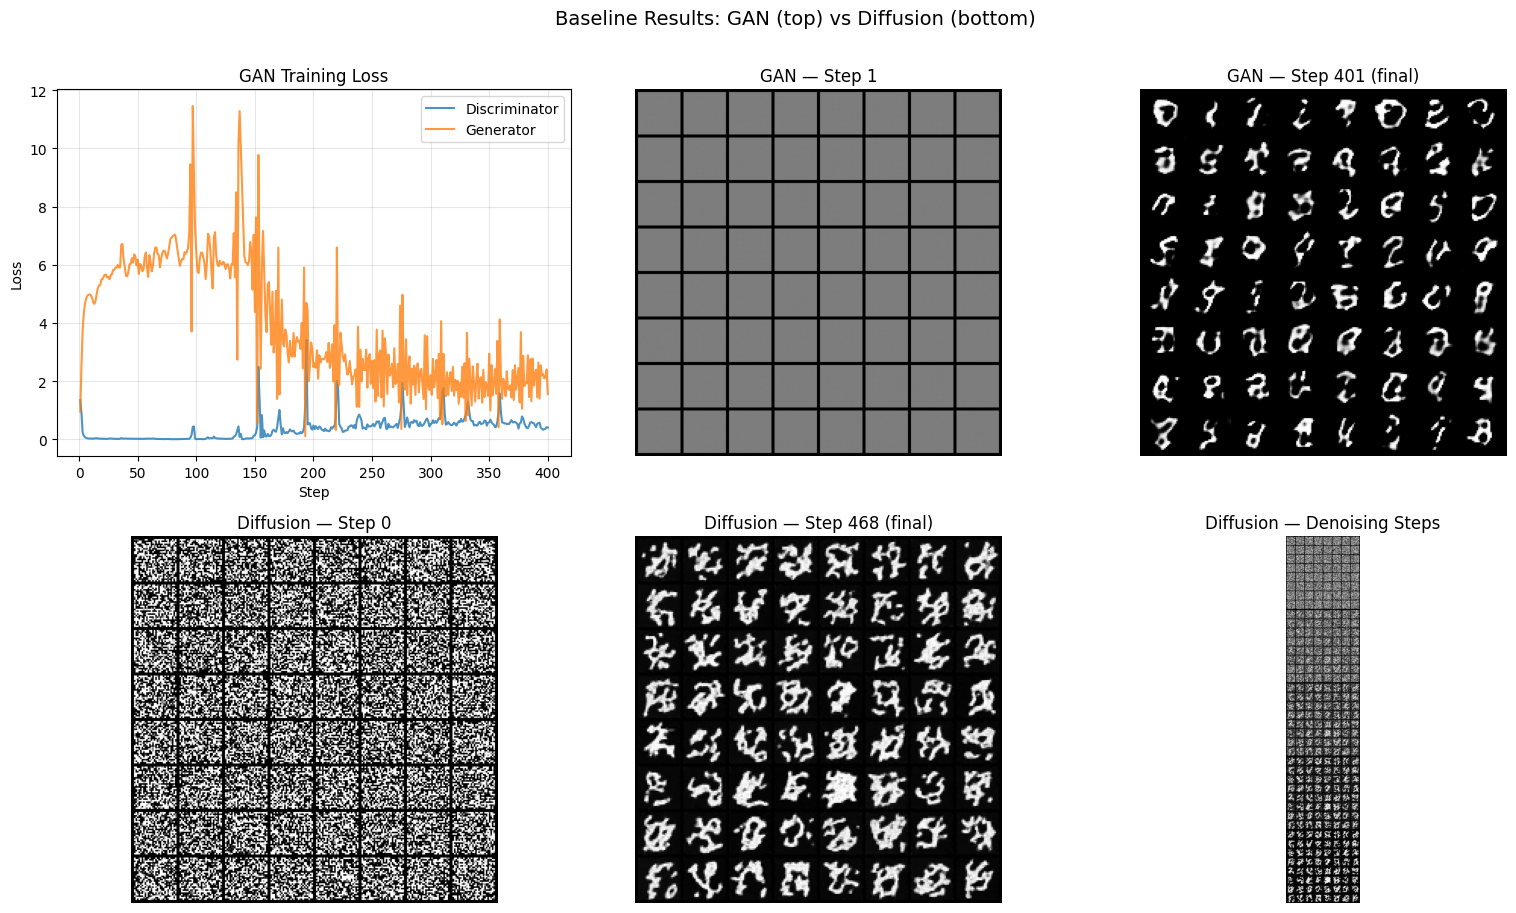

In [4]:
gan_summary = read_json(GAN_BASELINE / 'summary.json')
gan_log = pd.read_csv(GAN_BASELINE / 'train_log.csv')
diff_summary = read_json(DIFF_BASELINE / 'summary.json')

print("=== GAN Baseline ===")
print(f"  Dataset: {gan_summary['dataset']}, Epochs: {gan_summary['epochs']}, Steps: {gan_summary['final_step']}")
print(f"  Runtime: {gan_summary['seconds']:.1f}s, Device: {gan_summary['device']}")
print(f"  lr={gan_summary['lr']}, z_dim={gan_summary['z_dim']}, base_ch={gan_summary['base_ch']}")

print(f"\n=== Diffusion Baseline (T={diff_summary['T']}, target={diff_summary['target']}, base_ch={diff_summary['base_ch']}) ===")
print(f"  Epochs: {diff_summary['epochs']}, Steps: {diff_summary['final_step']}")
print(f"  Runtime: {diff_summary['seconds']:.1f}s, Device: {diff_summary['device']}")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Row 1: GAN
axes[0][0].plot(gan_log['step'], gan_log['lossD'], label='Discriminator', alpha=0.8)
axes[0][0].plot(gan_log['step'], gan_log['lossG'], label='Generator', alpha=0.8)
axes[0][0].set_xlabel('Step')
axes[0][0].set_ylabel('Loss')
axes[0][0].set_title('GAN Training Loss')
axes[0][0].legend()
axes[0][0].grid(True, alpha=0.3)

gan_grid_early = GAN_BASELINE / 'samples' / 'grid_step000001.png'
gan_grid_final = GAN_BASELINE / 'samples' / 'grid_step000401.png'
axes[0][1].imshow(mpimg.imread(str(gan_grid_early)))
axes[0][1].set_title('GAN — Step 1')
axes[0][1].axis('off')
axes[0][2].imshow(mpimg.imread(str(gan_grid_final)))
axes[0][2].set_title('GAN — Step 401 (final)')
axes[0][2].axis('off')

# Row 2: Diffusion
diff_early = DIFF_BASELINE / 'samples' / 'samples_step000000.png'
diff_final = DIFF_BASELINE / 'samples' / 'samples_step000468.png'
diff_denoise = DIFF_BASELINE / 'samples' / 'denoise_steps_step000468.png'
axes[1][0].imshow(mpimg.imread(str(diff_early)))
axes[1][0].set_title('Diffusion — Step 0')
axes[1][0].axis('off')
axes[1][1].imshow(mpimg.imread(str(diff_final)))
axes[1][1].set_title('Diffusion — Step 468 (final)')
axes[1][1].axis('off')
axes[1][2].imshow(mpimg.imread(str(diff_denoise)))
axes[1][2].set_title('Diffusion — Denoising Steps')
axes[1][2].axis('off')

plt.suptitle('Baseline Results: GAN (top) vs Diffusion (bottom)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Visualize samples

For diffusion runs, the starter saves PNG grids in each run directory (`samples/`).
We load the latest sample grid for each run and show a contact sheet.

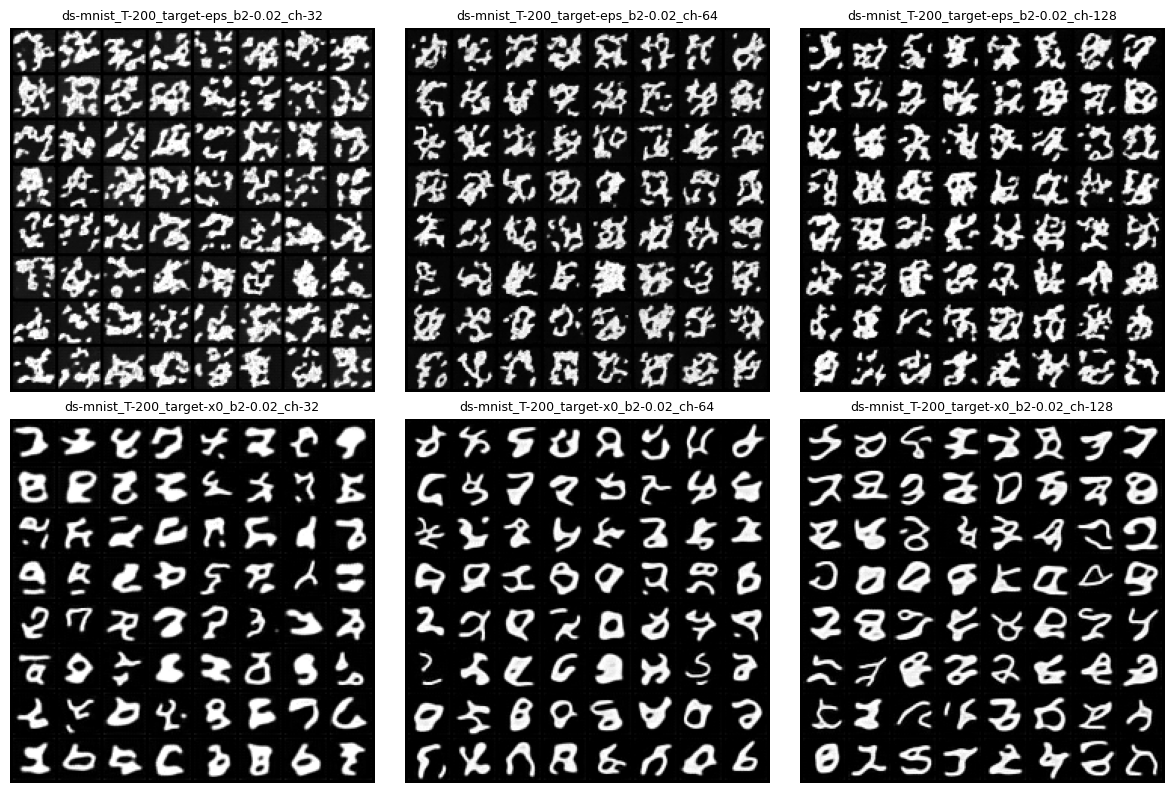

In [5]:
def find_pngs(run_dir: Path):
    candidates = []
    if (run_dir / 'samples').exists():
        candidates += sorted((run_dir / 'samples').glob('*.png'))
    candidates += sorted(run_dir.glob('*.png'))
    candidates = sorted(candidates, key=lambda p: (('grid' not in p.name.lower() and 'sample' not in p.name.lower()), -p.stat().st_mtime))
    return candidates

imgs = []
titles = []
for rd in df['run_dir']:
    rd = Path(rd)
    pngs = find_pngs(rd)
    if pngs:
        imgs.append(pngs[0])
        titles.append(rd.name)

n = len(imgs)
ncols = 3
nrows = (n + ncols - 1) // ncols
plt.figure(figsize=(4*ncols, 4*nrows))
for i, (p, t) in enumerate(zip(imgs, titles), start=1):
    ax = plt.subplot(nrows, ncols, i)
    ax.imshow(mpimg.imread(str(p)))
    ax.set_title(t, fontsize=9)
    ax.axis('off')
plt.tight_layout()

## 5. Simple diversity proxy and run time

A lightweight metric for diffusion samples: average pairwise L2 distance in pixel space on a subset.

*Higher values suggest more varied outputs; very low values may indicate mode collapse.*

In [6]:
runtime_rows = []
for _, row in df.iterrows():
    rd = Path(row['run_dir'])
    summary_path = rd / "summary.json"
    if summary_path.exists():
        with open(summary_path) as f:
            s = json.load(f)
        runtime_rows.append({
            'name': rd.name,
            'target': row['target'],
            'base_ch': int(row['base_ch']),
            'runtime_s': round(s['seconds'], 2),
        })

rt_df = pd.DataFrame(runtime_rows)
print("=== Training Runtime (seconds) ===")
rt_df

=== Training Runtime (seconds) ===


,name,target,base_ch,runtime_s
0,ds-mnist_T-200_target-eps_b2-0.02_ch-32,eps,32,38.24
1,ds-mnist_T-200_target-eps_b2-0.02_ch-64,eps,64,86.66
2,ds-mnist_T-200_target-eps_b2-0.02_ch-128,eps,128,252.28
3,ds-mnist_T-200_target-x0_b2-0.02_ch-32,x0,32,38.05
4,ds-mnist_T-200_target-x0_b2-0.02_ch-64,x0,64,86.47
5,ds-mnist_T-200_target-x0_b2-0.02_ch-128,x0,128,250.10


In [7]:
from PIL import Image

def load_grid_as_tiles(png_path: Path, tile_h: int = 28, tile_w: int = 28, padding: int = 2):
    """Load a sample grid PNG and split it into individual sample tiles."""
    img = np.array(Image.open(png_path).convert('L'))
    tiles = []
    y = padding
    while y + tile_h <= img.shape[0]:
        x = padding
        while x + tile_w <= img.shape[1]:
            tile = img[y:y+tile_h, x:x+tile_w]
            if tile.shape == (tile_h, tile_w):
                tiles.append(tile)
            x += tile_w + padding
        y += tile_h + padding
    return np.array(tiles) if tiles else np.zeros((0, tile_h, tile_w))

def diversity_proxy(tiles: np.ndarray, n_pairs: int = 512) -> float:
    """Average pairwise L2 distance between sample tiles."""
    flat = tiles.reshape(len(tiles), -1).astype(np.float32) / 255.0
    n = len(flat)
    if n < 2:
        return float('nan')
    rng = np.random.default_rng(0)
    idx = rng.integers(0, n, size=(min(n_pairs, n * n), 2))
    dists = np.linalg.norm(flat[idx[:, 0]] - flat[idx[:, 1]], axis=1)
    return float(dists.mean())

diversity_rows = []
for _, row in df.iterrows():
    rd = Path(row['run_dir'])
    pngs = find_pngs(rd)
    if pngs:
        tiles = load_grid_as_tiles(pngs[0])
        div = diversity_proxy(tiles)
    else:
        tiles, div = [], float('nan')
    diversity_rows.append({
        'name': rd.name,
        'target': row['target'],
        'base_ch': int(row['base_ch']),
        'n_tiles': len(tiles),
        'diversity': round(div, 4),
    })

div_df = pd.DataFrame(diversity_rows)
print("=== Pixel-Space Diversity Proxy (avg pairwise L2) ===")
div_df


=== Pixel-Space Diversity Proxy (avg pairwise L2) ===


,name,target,base_ch,n_tiles,diversity
0,ds-mnist_T-200_target-eps_b2-0.02_ch-32,eps,32,64,13.4493
1,ds-mnist_T-200_target-eps_b2-0.02_ch-64,eps,64,64,11.6158
2,ds-mnist_T-200_target-eps_b2-0.02_ch-128,eps,128,64,12.6904
3,ds-mnist_T-200_target-x0_b2-0.02_ch-32,x0,32,64,11.2202
4,ds-mnist_T-200_target-x0_b2-0.02_ch-64,x0,64,64,11.4975
5,ds-mnist_T-200_target-x0_b2-0.02_ch-128,x0,128,64,12.2375


## 6. Failure modes & limitations

### Failure Mode 1: eps Parameterization Produces Noise result

With `target=eps` and `base_ch=32`,  the model outputs large white blob-like masses with little recognizable digit structure. In contrast, `target=x0` at the same capacity already produces identifiable, though distorted, digits. The same qualitative pattern remains visible at higher capacities: across all tested base_ch values, eps samples appear noisier and less structured than x0 samples in this 1-epoch setting.

**Likely cause:** : In the eps parameterization, the network predicts the noise component and the reverse process reconstructs the image from that prediction. Under short training and limited capacity, errors in noise prediction may propagate through the 200-step reverse process, leading to visibly degraded samples. By contrast, the x0 parameterization directly predicts the clean image, which may provide a more accessible learning target in this underfitted regime: even an approximate x0 prediction can already produce digit-like structure, whereas approximate eps predictions may translate into noisier reconstructions.

### Failure Mode 2: Misleading Diversity Proxy for Underfitted eps Models

The pixel-space diversity proxy shows eps/ch=32 with the **highest** diversity (13.45), yet the sample grid reveals these are just random noise blobs — not meaningful diversity. Meanwhile, x0/ch=32 has lower diversity (11.22) but produces actual recognizable digits.

**Likely cause:** The diversity proxy measures pairwise L2 distance in pixel space. Random, unstructured outputs are all different from each other (high L2), while recognizable digits share common structures (strokes, shapes) that reduce L2 distance. This metric cannot distinguish "diverse because noise" from "diverse because rich generation." This is a fundamental limitation of pixel-space diversity metrics.

### Failure Mode 3: GAN Limited Diversity at Short Training

The DCGAN baseline produces recognizable digits but still shows signs of limited diversity. Some samples cluster around similar digit styles. The discriminator loss drops quickly while the generator loss rises early in training, which is consistent with the discriminator learning faster than the generator in the early stage.

**Likely cause:** With very short training, the adversarial equilibrium is never reached. The generator has not yet explored the full data distribution.

### Limitations

- **Single epoch training:** All diffusion runs use only 1 epoch. This is sufficient for MNIST to show trends but may not fully converge, especially for larger models that need more passes.
- **Diversity proxy is misleading for underfitted models:** As shown above, the pixel-space L2 metric reports artificially high diversity for noisy/failed outputs. A perceptual metric (e.g., FID) would better distinguish quality from randomness.


## 7. Conclusions

- In this short-training MNIST regime, x0 parameterization visually outperforms eps. Across all tested base_ch values, x0 produces more recognizable and structured digits, while eps remains noisier and less stable, especially at low capacity. This is the clearest qualitative finding of the experiment.

- Increasing model capacity (base_ch) improves sample quality for both parameterizations, with a larger apparent benefit for eps. At ch=32, eps largely fails while x0 already produces recognizable digits. By ch=128, both improve, although x0 still appears visually stronger in this 1-epoch setting.

- The eps/ch=32 failure is consistent with the idea that noise-prediction errors may propagate through the 200-step reverse process under underfitting. In contrast, direct x0 prediction may provide a more accessible learning target in this short-training regime, allowing digit-like structure to emerge earlier even before full convergence.

- The diversity proxy is unreliable for underfitted models. eps/ch=32 receives the highest diversity score (13.45) despite producing the worst samples, because random unstructured outputs can be highly separated in pixel space. This highlights an important limitation of pixel-space diversity metrics.

- Runtime increases fast with base_ch (~38s at ch=32, ~90s at ch=64, ~250s at ch=128), which is broadly consistent with the rapid growth in model size and compute cost. The choice of target parameterization appears to have little impact on runtime.

- The GAN baseline shows a different failure pattern from diffusion under limited training. After 1 epoch, the GAN already produces recognizable digits, but sample variety still appears somewhat limited. This contrasts with the diffusion baseline, which tends to fail through noisy or blob-like outputs rather than reduced variety, suggesting that different generative paradigms fail in qualitatively different ways under short training.

- **Next step:** Extending training to more epochs would test whether eps eventually catches up to x0, or whether x0 retains an advantage in short and simple settings such as MNIST.
